In [12]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [13]:
# ==========================================
# 1. ATUR JALUR DATASET (Sesuai Laptop Anda)
# ==========================================
# Pastikan di dalam folder 'train' dan 'test' terdapat folder 'cats' dan 'dogs'
TRAIN_DIR = r"C:\CNN\training_set"
VALIDATION_DIR = r"C:\CNN\test_set"

IMG_SIZE = (64, 64)
BATCH_SIZE = 16

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# ==========================================
# 2. PROSES MEMBACA GAMBAR (Data Loader)
# ==========================================
print("Sedang memuat dataset...")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)
validation_datagen = ImageDataGenerator(rescale=1./255)

try:
    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    validation_generator = validation_datagen.flow_from_directory(
        VALIDATION_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )
except Exception as e:
    print(f"\n[ERROR] Gagal membaca folder. Pesan Error: {e}")
    print("Silakan cek kembali apakah folder 'train' dan 'test' sudah benar strukturnya.")
    exit()

Sedang memuat dataset...
Found 8005 images belonging to 1 classes.
Found 2023 images belonging to 1 classes.


In [15]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Output biner (0 = Kucing, 1 = Anjing)
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
# ==========================================
# 4. PROSES TRAINING
# ==========================================
print("\nMemulai training model AI... Proses ini memakan waktu beberapa menit.")
epochs = 10 # Anda bisa menambahkannya nanti (misal: 20) jika ingin lebih akurat

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

print("\nTraining Selesai Berhasil!")


Memulai training model AI... Proses ini memakan waktu beberapa menit.
Epoch 1/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9994 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 5.2196e-30
Epoch 2/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 1.0000 - loss: 7.6597e-33 - val_accuracy: 1.0000 - val_loss: 5.2196e-30
Epoch 3/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 1.0000 - loss: 5.0312e-31 - val_accuracy: 1.0000 - val_loss: 5.2196e-30
Epoch 4/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 1.0000 - loss: 2.3550e-29 - val_accuracy: 1.0000 - val_loss: 5.2196e-30
Epoch 5/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 1.0000 - loss: 5.6155e-30 - val_accuracy: 1.0000 - val_loss: 5.2196e-30
Epoch 6/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 1.0000 - loss: 3.0018e-30 - val_accuracy: 1.0000 - val_loss: 5.2196e-30
Epoch 7/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 1.0000 - loss: 1.5062e-30 - val_accurac

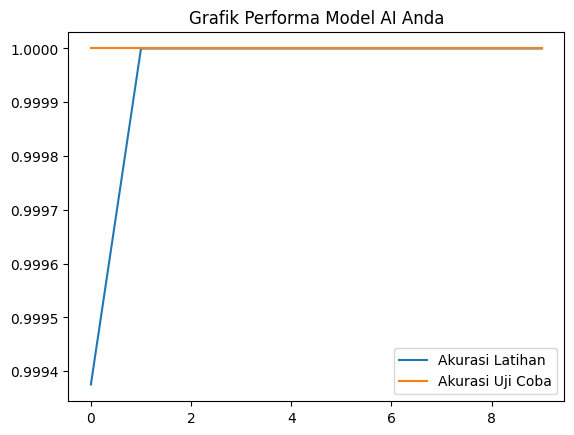

Model berhasil disimpan dengan nama 'model_kucing_anjing.keras'!


In [18]:
# ==========================================
# 5. MENAMPILKAN GRAFIK AKURASI
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(range(epochs), acc, label='Akurasi Latihan')
plt.plot(range(epochs), val_acc, label='Akurasi Uji Coba')
plt.legend()
plt.title('Grafik Performa Model AI Anda')
plt.show()

# TEPAT DI BAWAH plt.show()
# Menyimpan model ke dalam file bernama 'model_kucing_anjing.keras'
model.save('model_kucing_anjing.keras')
print("Model berhasil disimpan dengan nama 'model_kucing_anjing.keras'!")